# 📊 Pitch Maps: Player Tracking by Phase of Play

This tutorial demonstrates how to merge tracking data with SkillCorner **Phases of Play** data to generate tactical team pitch maps, calculate team spatial metrics (Width, Depth, Height), and visualize team shape across different in-possession and out-of-possession phases.

## 📋 Step 1: Setup & Prerequisites

Make sure you have the required open-source libraries installed:
```bash
pip install numpy pandas matplotlib scipy mplsoccer skillcornerviz
```

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from mplsoccer import Pitch
from skillcornerviz.utils import constants


## 📥 Step 2: Load Open Data (Match Metadata, Tracking & Phases of Play)

We load the open match dataset for `match_id = 1886347` directly from local files.

In [2]:
match_id = 1886347
data_dir = f"../../../data/matches/{match_id}"

# 1. Load Match Metadata
with open(f"{data_dir}/{match_id}_match.json") as f:
    raw_match_data = json.load(f)

raw_match_df = pd.json_normalize(raw_match_data, max_level=2)
players_df = pd.json_normalize(
    raw_match_df.to_dict("records"),
    record_path="players",
    meta=["home_team.name", "home_team.id", "away_team.name", "away_team.id", "home_team_side"]
)

def time_to_seconds(t_str):
    if not t_str or pd.isna(t_str):
        return 0
    parts = str(t_str).split(":")
    return float(parts[0]) * 3600 + float(parts[1]) * 60 + float(parts[2])

players_df = players_df[~((players_df["start_time"].isna()) & (players_df["end_time"].isna()))].copy()
players_df["total_time"] = players_df["end_time"].apply(time_to_seconds) - players_df["start_time"].apply(time_to_seconds)
players_df["is_gk"] = players_df["player_role.acronym"] == "GK"
players_df["game"] = players_df["home_team.name"] + " vs " + players_df["away_team.name"]
players_df["home_away_player"] = np.where(players_df["team_id"] == players_df["home_team.id"], "Home", "Away")

# Extract playing directions per half
players_df[["home_team_side_1st_half", "home_team_side_2nd_half"]] = (
    players_df["home_team_side"]
    .astype(str)
    .str.strip("[]")
    .str.replace("'", "")
    .str.split(", ", expand=True)
)
players_df["direction_player_1st_half"] = np.where(
    players_df["home_away_player"] == "Home",
    players_df["home_team_side_1st_half"],
    players_df["home_team_side_2nd_half"]
)
players_df["direction_player_2nd_half"] = np.where(
    players_df["home_away_player"] == "Home",
    players_df["home_team_side_2nd_half"],
    players_df["home_team_side_1st_half"]
)

# Select top 10 outfield players + 1 goalkeeper per team (starters)
outfield = players_df[~players_df["is_gk"]].groupby("team_id", group_keys=False).apply(lambda x: x.nlargest(10, "total_time")).reset_index(drop=True)
gk = players_df[players_df["is_gk"]].groupby("team_id", group_keys=False).apply(lambda x: x.nlargest(1, "total_time")).reset_index(drop=True)
selected_players = pd.concat([outfield, gk], ignore_index=True)

# 2. Load Tracking & Phases Data
raw_tracking = pd.read_json(f"{data_dir}/{match_id}_tracking_extrapolated.jsonl", lines=True)
tracking_df = pd.json_normalize(
    raw_tracking.to_dict("records"),
    "player_data",
    ["frame", "timestamp", "period", "possession", "ball_data"]
)
tracking_df["possession.group"] = tracking_df["possession"].apply(lambda x: x.get("group") if isinstance(x, dict) else None)

phases_df = pd.read_csv(f"{data_dir}/{match_id}_phases_of_play.csv")


/var/folders/vg/hbdnhqg500z2njwry3wyth400000gn/T/ipykernel_12839/1811529072.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outfield = players_df[~players_df["is_gk"]].groupby("team_id", group_keys=False).apply(lambda x: x.nlargest(10, "total_time")).reset_index(drop=True)
/var/folders/vg/hbdnhqg500z2njwry3wyth400000gn/T/ipykernel_12839/1811529072.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gk

## ⚙️ Step 3: Map Tracking Frames to Phases of Play

We map frame coordinates to their corresponding phase of play based on frame intervals and possession state.

In [3]:
main_df = tracking_df[tracking_df["possession.group"].notnull()].copy()
grouped = main_df.merge(
    selected_players[["team_id", "player_role.name", "id", "first_name", "short_name", "start_time", "end_time", "number", "home_team.name", "away_team.name", "game", "home_away_player", "direction_player_1st_half", "direction_player_2nd_half", "is_gk"]],
    left_on="player_id", right_on="id"
)

grouped["direction_player"] = np.where(grouped["period"] == 1, grouped["direction_player_1st_half"], grouped["direction_player_2nd_half"])
grouped["x"] = np.where(grouped["direction_player"] == "right_to_left", -grouped["x"], grouped["x"])
grouped["y"] = np.where(grouped["direction_player"] == "right_to_left", -grouped["y"], grouped["y"])
grouped["team"] = np.where(grouped["home_away_player"] == "Home", grouped["home_team.name"], grouped["away_team.name"])

interval_index = pd.IntervalIndex.from_arrays(phases_df["frame_start"], phases_df["frame_end"], closed="left")
matched_idx = interval_index.get_indexer(grouped["frame"])

valid_mask = matched_idx != -1
tracking_valid = grouped[valid_mask].copy().reset_index(drop=True)
matched_phases = phases_df.iloc[matched_idx[valid_mask]].reset_index(drop=True)

combined = tracking_valid.join(matched_phases[["team_in_possession_id", "team_in_possession_phase_type", "team_out_of_possession_phase_type"]])
combined["phase"] = np.where(
    combined["team_id"] == combined["team_in_possession_id"],
    combined["team_in_possession_phase_type"],
    combined["team_out_of_possession_phase_type"]
)


## 📊 Step 4: Calculate Average Positions by Phase of Play

We compute the mean `x` and `y` coordinates for each player grouped by phase of play.

In [4]:
aggregated_df = combined.groupby(["player_id", "team", "number", "is_gk", "phase"])[["x", "y"]].mean().reset_index()
game_title = grouped["game"].iloc[0]
aggregated_df.head()


,player_id,team,number,is_gk,phase,x,y
0,14736,Auckland FC,6,False,build_up,-20.011265,-5.168121
1,14736,Auckland FC,6,False,chaotic,-1.027665,-1.169192
2,14736,Auckland FC,6,False,create,0.255969,-5.309768
3,14736,Auckland FC,6,False,defending_direct,5.626399,-6.635042
4,14736,Auckland FC,6,False,defending_set_play,-37.819528,-10.389738


## 🎨 Step 5: Visualize Pitch Maps & Team Shape Metrics

We plot the average positions, convex hull, width, depth, and team height for each phase of play.

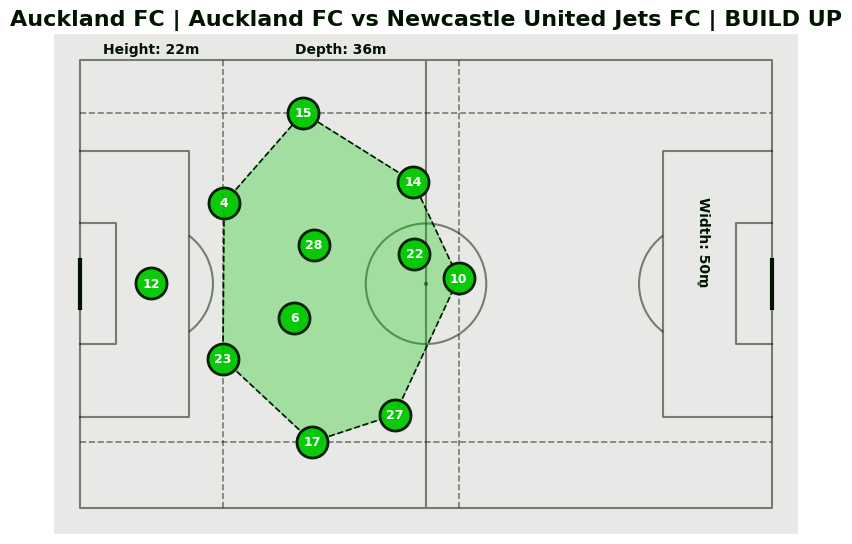

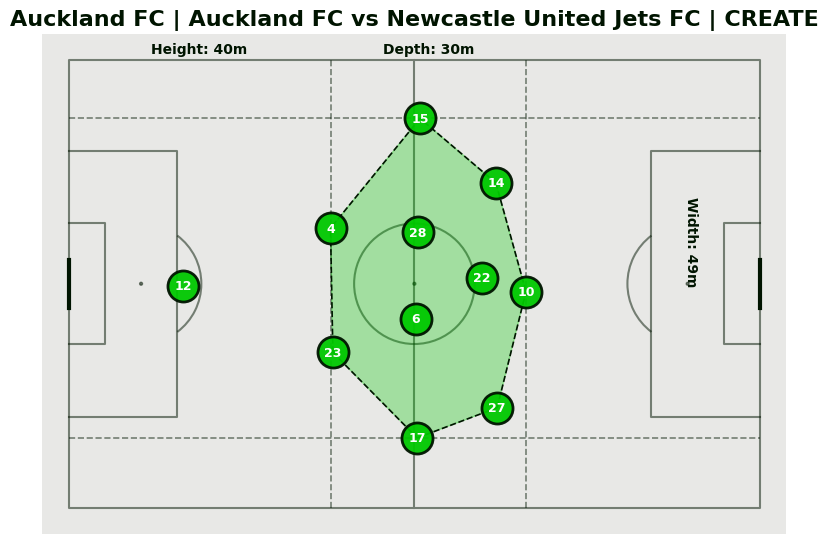

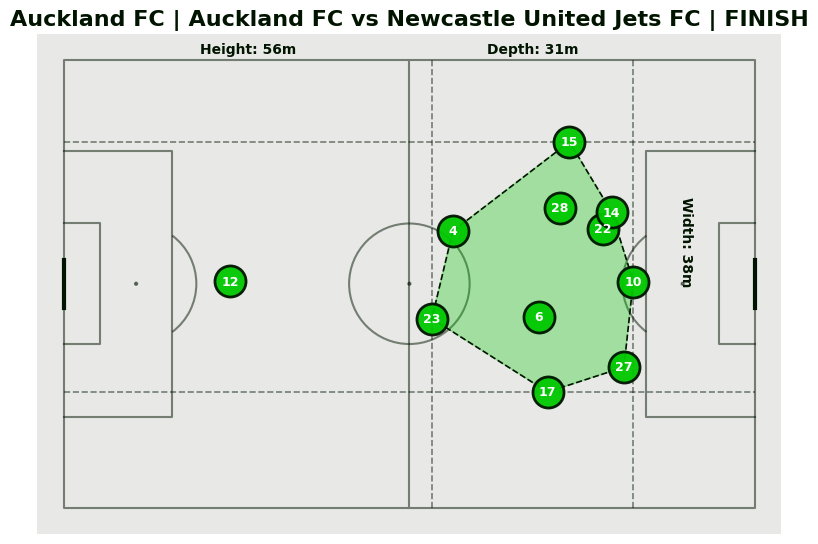

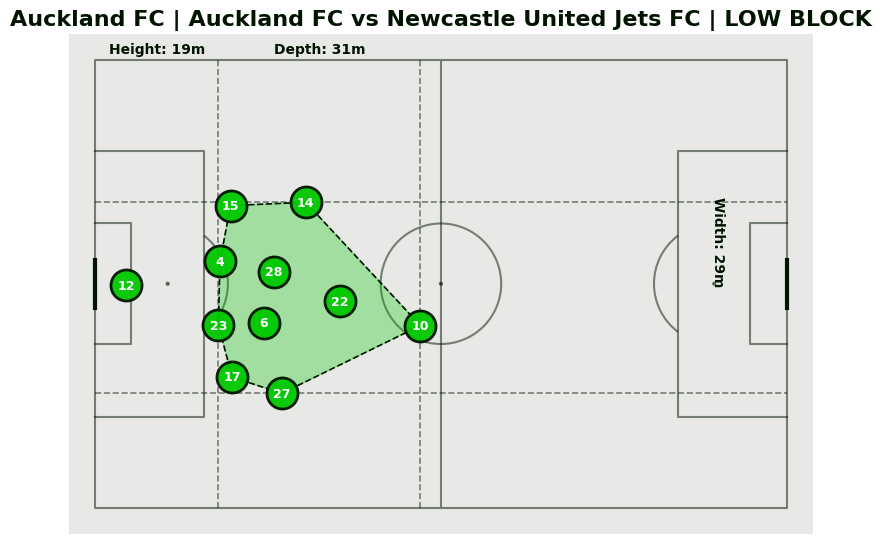

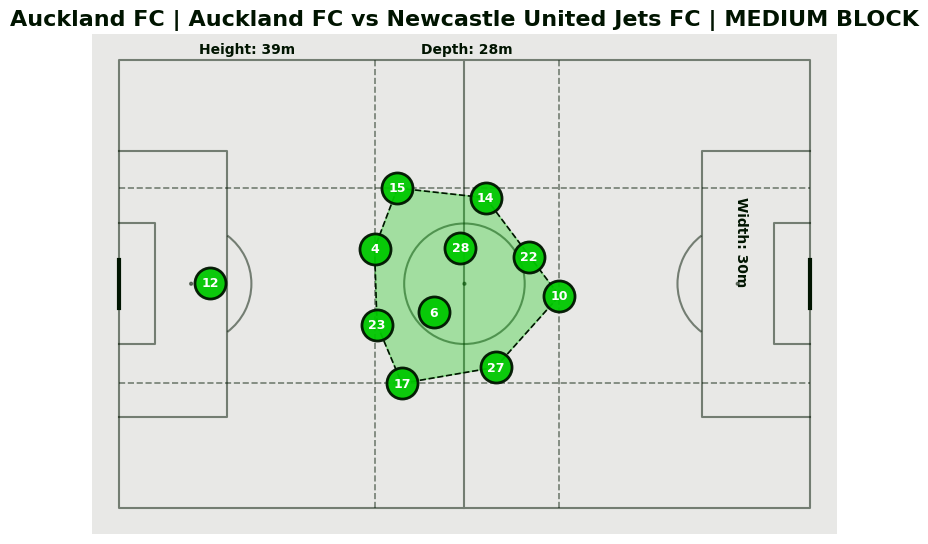

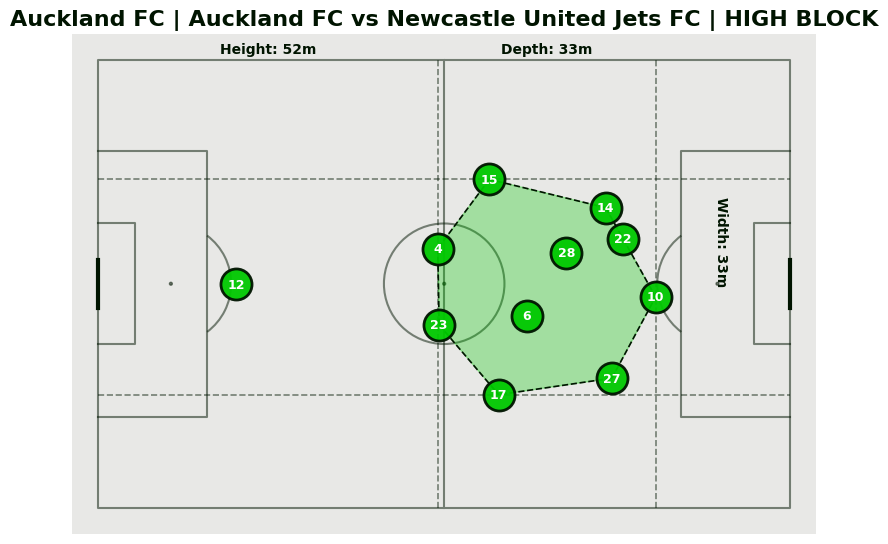

In [5]:
def plot_team_positions(ax, data, color, edge_color, text_color, label, include_area=False):
    points = data[~data["is_gk"]][["x", "y"]].values
    if len(points) > 2:
        hull = ConvexHull(points)
        ax.fill(points[hull.vertices, 0], points[hull.vertices, 1], color=color, alpha=0.3, zorder=8)
        for simplex in hull.simplices:
            ax.plot(points[simplex, 0], points[simplex, 1], color=edge_color, linestyle="--", linewidth=1.2, zorder=8)

    ax.scatter(data["x"], data["y"], c=color, alpha=0.95, s=500, edgecolors=edge_color, linewidths=2.0, zorder=10, label=label)

    for _, row in data.iterrows():
        ax.text(row["x"], row["y"], str(int(row["number"])), color=text_color, fontweight="bold", fontsize=9, ha="center", va="center", zorder=11)

team_name = aggregated_df["team"].unique()[0]
phase_list = ["build_up", "create", "finish", "low_block", "medium_block", "high_block"]

for phase_type in phase_list:
    viz_phase = aggregated_df[(aggregated_df["phase"] == phase_type) & (aggregated_df["team"] == team_name)].reset_index(drop=True)
    if viz_phase.empty:
        continue

    pitch = Pitch(pitch_type="skillcorner", line_alpha=0.5, pitch_length=105, pitch_width=68, pitch_color="#e8e8e6", line_color=constants.TEXT_COLOR, linewidth=1.5)
    fig, ax = pitch.grid(figheight=7, endnote_height=0, title_height=0)

    plot_team_positions(ax, viz_phase, color=constants.PRIMARY_HIGHLIGHT_COLOR, edge_color=constants.TEXT_COLOR, text_color="white", label=phase_type.replace("_", " ").upper())

    ax.set_title(f"{team_name} | {game_title} | {phase_type.replace('_', ' ').upper()}", size=16, fontweight="bold", color=constants.TEXT_COLOR)

    # Calculate spatial bounds (excluding Goalkeeper)
    field_players = viz_phase[~viz_phase["is_gk"]]
    if not field_players.empty:
        depth = field_players["x"].min()
        top = field_players["x"].max()
        bot_v = field_players["y"].min()
        top_v = field_players["y"].max()

        spread = round(top_v - bot_v)
        team_depth = round(top - depth)
        team_height = abs(round(depth + 52.5))

        # Draw spatial reference lines
        ax.plot([depth, depth], [-34, 34], ls="--", color=constants.TEXT_COLOR, linewidth=1.2, alpha=0.5)
        ax.plot([top, top], [-34, 34], ls="--", color=constants.TEXT_COLOR, linewidth=1.2, alpha=0.5)
        ax.plot([-52.5, 52.5], [bot_v, bot_v], ls="--", color=constants.TEXT_COLOR, linewidth=1.2, alpha=0.5)
        ax.plot([-52.5, 52.5], [top_v, top_v], ls="--", color=constants.TEXT_COLOR, linewidth=1.2, alpha=0.5)

        # Annotate Width, Height, and Depth
        ax.text(x=abs(40) * 1.05, y=0, s=f"Width: {spread}m", weight="bold", rotation=270, ha="center", color=constants.TEXT_COLOR)
        ax.text(x=(-52.5 + depth) / 2, y=34 * 1.03, s=f"Height: {team_height}m", weight="bold", ha="center", color=constants.TEXT_COLOR)
        ax.text(x=(depth + top) / 2, y=34 * 1.03, s=f"Depth: {team_depth}m", weight="bold", ha="center", color=constants.TEXT_COLOR)

    plt.show()
